In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [4]:
# NAV history
nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Scheme performance
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

# Investor transactions
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

# Portfolio holdings
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Fund master
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [5]:
print("NAV Columns:")
print(nav.columns)

print("\nPerformance Columns:")
print(performance.columns)

print("\nTransaction Columns:")
print(transactions.columns)

print("\nHoldings Columns:")
print(holdings.columns)

print("\nFund Master Columns:")
print(fund_master.columns)

NAV Columns:
Index(['amfi_code', 'date', 'nav'], dtype='object')

Performance Columns:
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

Transaction Columns:
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Holdings Columns:
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

Fund Master Columns:
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_dat

In [6]:
# Convert date column
nav['date'] = pd.to_datetime(nav['date'])

# Sort data
nav = nav.sort_values(['amfi_code', 'date'])

# View first rows
nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [7]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [8]:
results = []

for code, grp in nav.groupby('amfi_code'):

    returns = grp['daily_return'].dropna()

    # 5th percentile
    var95 = np.percentile(returns, 5)

    # Average returns below VaR
    cvar95 = returns[returns <= var95].mean()

    results.append({
        'amfi_code': code,
        'VaR_95': var95,
        'CVaR_95': cvar95
    })

var_df = pd.DataFrame(results)

In [9]:
var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [12]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv created successfully")

var_cvar_report.csv created successfully


## Rolling 90 Day Sharpe Ratio

In [16]:
rolling_sharpe = (
    nav.groupby('amfi_code')['daily_return']
    .rolling(90)
    .apply(
        lambda x: (x.mean()/x.std()) * np.sqrt(252)
        if x.std() != 0 else np.nan
    )
    .reset_index()
)

rolling_sharpe.columns = [
    'amfi_code',
    'index',
    'rolling_sharpe'
]

rolling_sharpe.head()

,amfi_code,index,rolling_sharpe
0,100016,5750,NaN
1,100016,5751,NaN
2,100016,5752,NaN
3,100016,5753,NaN
4,100016,5754,NaN


In [17]:
top5_funds = (
    performance
    .sort_values('sharpe_ratio', ascending=False)
    .head(5)
)

top5_funds[['amfi_code','scheme_name','sharpe_ratio']]

,amfi_code,scheme_name,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


In [18]:
rolling_sharpe['date'] = nav.loc[
    rolling_sharpe['index'],
    'date'
].values

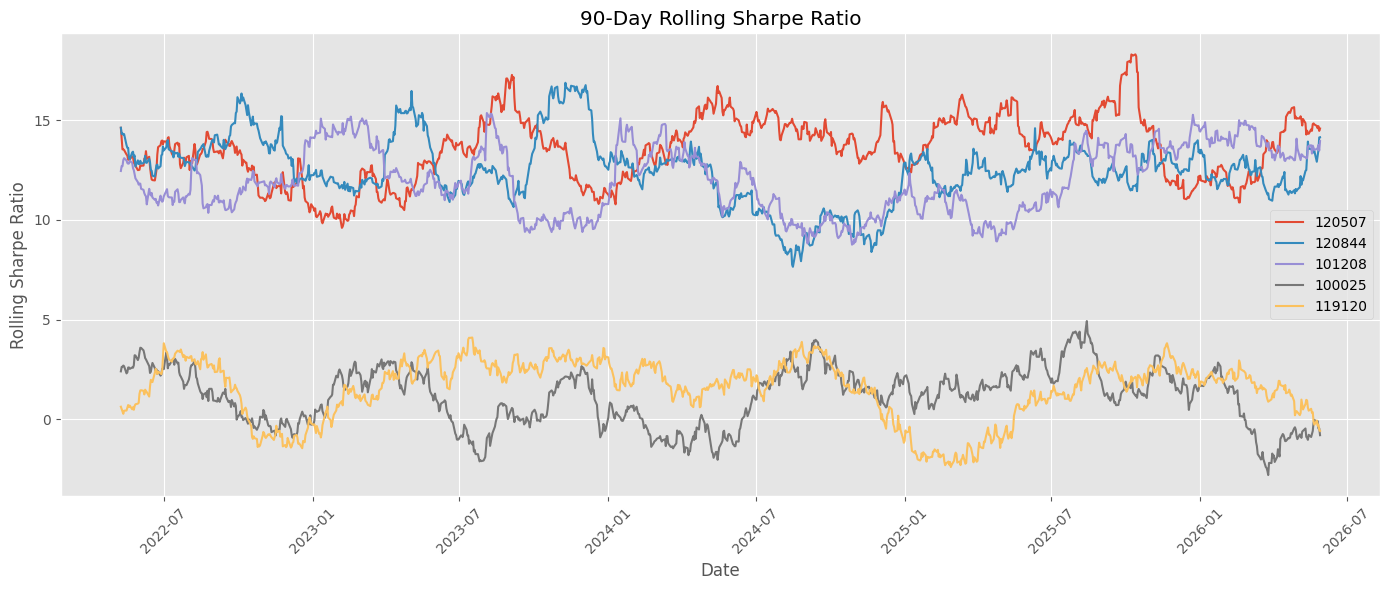

In [20]:
import os

os.makedirs("../reports/charts", exist_ok=True)

plt.figure(figsize=(14,6))

for code in top5_funds['amfi_code']:

    temp = rolling_sharpe[
        rolling_sharpe['amfi_code']==code
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(code)
    )

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.title("90-Day Rolling Sharpe Ratio")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png"
)

plt.show()

## Investor Cohort Analysis

In [21]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [22]:
transactions['cohort_year'] = (
    transactions.groupby('investor_id')['transaction_date']
    .transform('min')
    .dt.year
)

transactions[
    ['investor_id','transaction_date','cohort_year']
].head()

,investor_id,transaction_date,cohort_year
0,INV003054,2024-01-01,2024
1,INV002952,2024-01-01,2024
2,INV003420,2024-01-01,2024
3,INV003436,2024-01-01,2024
4,INV004691,2024-01-01,2024


In [23]:
cohort_summary = (
    transactions.groupby('cohort_year')
    .agg(
        investors=('investor_id','nunique'),
        avg_investment=('amount_inr','mean'),
        total_investment=('amount_inr','sum')
    )
    .reset_index()
)

cohort_summary

,cohort_year,investors,avg_investment,total_investment
0,2024,4803,107422.541832,3491125187
1,2025,197,109158.577061,30455243


In [24]:
fund_preference = (
    transactions.groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(name='count')
)

In [25]:
top_funds = fund_preference.loc[
    fund_preference.groupby(
        'cohort_year'
    )['count'].idxmax()
]

top_funds

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [26]:
top_funds = top_funds.merge(
    fund_master[
        ['amfi_code','scheme_name']
    ],
    on='amfi_code',
    how='left'
)

top_funds

,cohort_year,amfi_code,count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [27]:
cohort_summary.to_csv(
    "../reports/cohort_summary.csv",
    index=False
)

top_funds.to_csv(
    "../reports/cohort_top_funds.csv",
    index=False
)

print("Cohort analysis reports created successfully.")

Cohort analysis reports created successfully.


## SIP Continuity Analysis

In [28]:
sip_investors = (
    transactions.groupby('investor_id')
    .filter(lambda x: len(x) >= 6)
)

sip_investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024


In [29]:
sip_investors = sip_investors.sort_values(
    ['investor_id', 'transaction_date']
)

sip_investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
17587,INV000002,2024-10-03,101207,Lumpsum,203094,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024


In [30]:
sip_investors['gap_days'] = (
    sip_investors.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

sip_investors.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,69.0
17587,INV000002,2024-10-03,101207,Lumpsum,203094,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,12.0
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,112.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,114.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
4863,INV000004,2024-03-17,118633,Lumpsum,78254,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,1.0
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,25.0
6501,INV000004,2024-04-12,149322,Redemption,290902,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,1.0


In [31]:
gap_analysis = (
    sip_investors.groupby('investor_id')
    .agg(
        avg_gap_days=('gap_days','mean')
    )
    .reset_index()
)

gap_analysis.head()

,investor_id,avg_gap_days
0,INV000002,82.800000
1,INV000004,53.375000
2,INV000005,52.000000
3,INV000006,99.000000
4,INV000008,50.285714


In [32]:
gap_analysis['status'] = np.where(
    gap_analysis['avg_gap_days'] > 35,
    'At Risk',
    'Healthy'
)

gap_analysis.head()

,investor_id,avg_gap_days,status
0,INV000002,82.800000,At Risk
1,INV000004,53.375000,At Risk
2,INV000005,52.000000,At Risk
3,INV000006,99.000000,At Risk
4,INV000008,50.285714,At Risk


In [33]:
gap_analysis['status'].value_counts()

status
At Risk    2762
Healthy     188
Name: count, dtype: int64

In [34]:
gap_analysis.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("sip_continuity_report.csv created successfully.")

sip_continuity_report.csv created successfully.


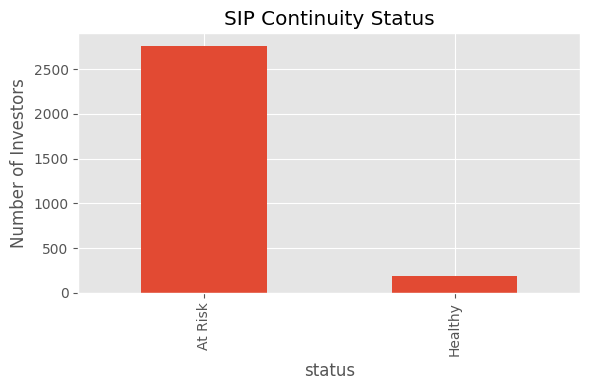

In [35]:
plt.figure(figsize=(6,4))

gap_analysis['status'].value_counts().plot(
    kind='bar'
)

plt.ylabel("Number of Investors")
plt.title("SIP Continuity Status")

plt.tight_layout()

plt.show()

## Portfolio Concentration Analysis using HHI

In [37]:
sector_weights = (
    holdings
    .groupby(
        ['amfi_code', 'sector']
    )['weight_pct']
    .sum()
)

sector_weights.head()

amfi_code  sector    
100016     Automobile    14.84
           Banking        3.39
           Energy         6.09
           FMCG          11.68
           IT            25.90
Name: weight_pct, dtype: float64

In [38]:
hhi = (
    sector_weights
    .pow(2)
    .groupby('amfi_code')
    .sum()
    .reset_index(name='HHI')
)

hhi.head()

,amfi_code,HHI
0,100016,1805.8808
1,100033,2276.4744
2,101206,1800.4225
3,101207,2227.2651
4,102885,1807.1202


In [39]:
hhi = hhi.merge(
    fund_master[
        ['amfi_code', 'scheme_name']
    ],
    on='amfi_code',
    how='left'
)

hhi.head()

,amfi_code,HHI,scheme_name
0,100016,1805.8808,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,2276.4744,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,1800.4225,ABSL Frontline Equity Fund - Regular - Growth
3,101207,2227.2651,ABSL Small Cap Fund - Regular - Growth
4,102885,1807.1202,UTI Nifty 50 Index Fund - Regular - Growth


In [40]:
hhi_sorted = hhi.sort_values(
    'HHI',
    ascending=False
)

hhi_sorted.head(10)

,amfi_code,HHI,scheme_name
11,119092,2967.6909,Axis Bluechip Fund - Regular - Growth
30,148569,2549.9194,Mirae Asset Tax Saver Fund - Regular - Growth
27,125498,2531.5500,HDFC Mid-Cap Opportunities Fund - Direct - Growth
6,102887,2513.8255,UTI Flexi Cap Fund - Regular - Growth
32,149323,2410.7664,DSP Midcap Fund - Regular - Growth
21,120505,2386.9504,ICICI Pru Midcap Fund - Regular - Growth
10,118635,2374.9677,Nippon India ETF Nifty 50 BeES
18,119599,2323.6120,SBI Small Cap Fund - Direct Plan - Growth
22,120506,2314.6434,ICICI Pru Value Discovery Fund - Regular - Growth
1,100033,2276.4744,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [41]:
hhi_sorted.to_csv(
    "../reports/hhi_concentration_report.csv",
    index=False
)

print("HHI report created successfully.")

HHI report created successfully.


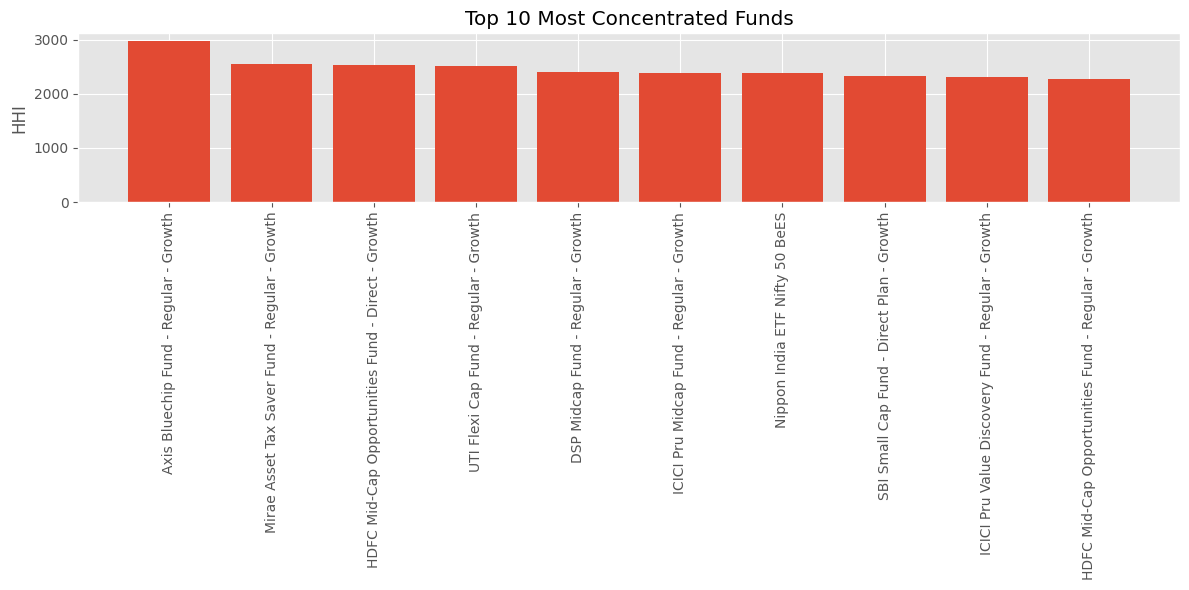

In [42]:
top10 = hhi_sorted.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['HHI']
)

plt.xticks(rotation=90)

plt.ylabel("HHI")

plt.title(
    "Top 10 Most Concentrated Funds"
)

plt.tight_layout()

plt.show()

In [43]:
print("""
1. Higher VaR funds experience larger downside losses.

2. Rolling Sharpe ratios identify funds with consistent risk-adjusted performance.

3. Older investor cohorts contribute significant investment amounts.

4. Most investors exhibit transaction gaps above 35 days, indicating SIP discontinuity risk.

5. Funds with high HHI values are concentrated in fewer sectors and are therefore less diversified.
""")


1. Higher VaR funds experience larger downside losses.

2. Rolling Sharpe ratios identify funds with consistent risk-adjusted performance.

3. Older investor cohorts contribute significant investment amounts.

4. Most investors exhibit transaction gaps above 35 days, indicating SIP discontinuity risk.

5. Funds with high HHI values are concentrated in fewer sectors and are therefore less diversified.

